In [1]:
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download NLTK resources
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

# Plot style
plt.style.use('dark_background')
sns.set_palette('muted')
ACCENT = '#6c63ff'

print('All imports successful ✓')

All imports successful ✓


---
1. Load dataset

In [3]:
df=pd.read_csv('../data/processed/Books_Cleaned.csv')
print(f'Shape          : {df.shape}')
print(f'Columns        : {df.columns.tolist()}')
print(f'Duplicate titles: {df.duplicated(subset="title").sum()}')
print(f'Missing values :\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Shape          : (16122, 25)
Columns        : ['book_id', 'title', 'authors', 'series', 'language', 'description', 'genres', 'characters', 'places', 'awards', 'rating', 'rating_count', 'review_count', 'popularity_score', 'award_count', 'pages', 'first_publish_year', 'publish_year', 'rated_1', 'rated_2', 'rated_3', 'rated_4', 'rated_5', 'isbn', 'isbn13']
Duplicate titles: 1135
Missing values :
description            1412
characters            12655
places                13225
awards                13895
first_publish_year     4567
isbn                   1608
isbn13                  202
dtype: int64


In [4]:
df.head(3)

,book_id,title,authors,series,language,description,genres,characters,places,awards,...,pages,first_publish_year,publish_year,rated_1,rated_2,rated_3,rated_4,rated_5,isbn,isbn13
0,4255,Harry Potter and the Philosopher's Stone,J.K. Rowling,Harry Potter #1,English,When a letter arrives for unhappy but ordinary...,"Fantasy,Fiction,Young Adult,Magic,Childrens,Mi...","Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",Mythopoeic Fantasy Award for Children's Litera...,...,223,1997.0,2004,126396,147247,627970,1694668,4840724,NaN,NaN
1,3,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré",Harry Potter #1,English,Harry Potter's life is miserable. His parents ...,"Fantasy,Fiction,Young Adult,Magic,Childrens,Mi...","Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",Mythopoeic Fantasy Award for Children's Litera...,...,309,1997.0,2003,126344,147184,627803,1694206,4839246,NaN,NaN
2,12024,Twilight,Stephenie Meyer,The Twilight Saga #1,English,"About three things I was absolutely positive.,...","Young Adult,Fantasy,Romance,Fiction,Paranormal...","Edward Cullen,Jacob Black,Laurent,Renee,Bella ...","Forks, Washington,Phoenix, Arizona,Washington ...","Georgia Peach Book Award 2007,Buxtehuder Bulle...",...,544,NaN,2005,562807,560978,1052619,1164865,1831810,NaN,9780316058988


In [5]:
#remove duplicates titles - keep first occurence 
df=df.drop_duplicates(subset='title').reset_index(drop=True)
print(f'After dedup: {len(df)} books')

After dedup: 14987 books


---
2. data overview

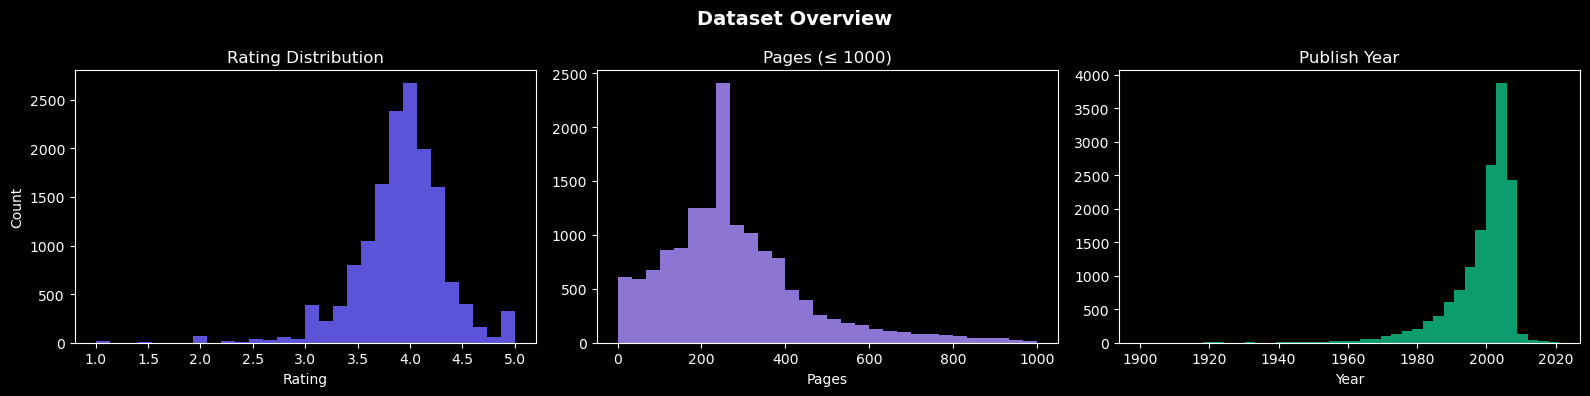

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Rating distribution
axes[0].hist(df['rating'].dropna(), bins=30, color=ACCENT, edgecolor='none', alpha=0.85)
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Count')

# Pages distribution (cap at 1000)
pages = df['pages'].dropna()
pages = pages[pages <= 1000]
axes[1].hist(pages, bins=30, color='#a78bfa', edgecolor='none', alpha=0.85)
axes[1].set_title('Pages (≤ 1000)')
axes[1].set_xlabel('Pages')

# Publish year
years = df['publish_year'].dropna()
years = years[(years >= 1900) & (years <= 2025)]
axes[2].hist(years, bins=40, color='#10b981', edgecolor='none', alpha=0.85)
axes[2].set_title('Publish Year')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

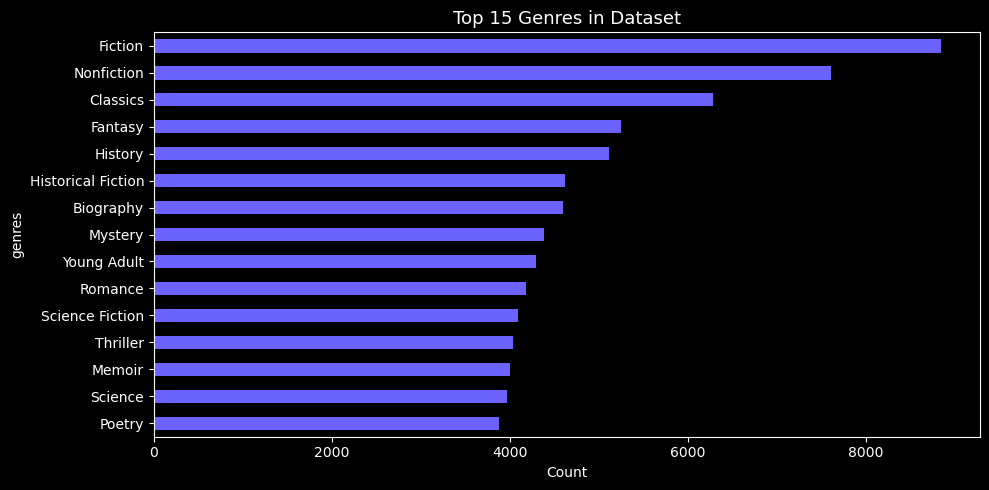

In [7]:
# Top 15 genres
all_genres = df['genres'].dropna().str.split(',').explode().str.strip()
top_genres = all_genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_genres.sort_values().plot(kind='barh', ax=ax, color=ACCENT, edgecolor='none')
ax.set_title('Top 15 Genres in Dataset', fontsize=13)
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

---
3. Nlp pipeline - step by step <br>

i build a single combined feature string per book from: title + authors + genres x2 + series x2 + description + places <br>

genres and series are repeated to give them higher TF-idf weight 

step 3.1 - Text claening

In [8]:
def clean_text(text):
    '''lowercase, remove sepcial char and numbers , strip extra space'''
    if not isinstance(text,str) or text.strip()=='':
        return ''
    text=text.lower()
    text=re.sub(r'[^a-z\s]', ' ', text) #keeping text only
    text=re.sub(r'\s+', ' ', text).strip()
    return text

# an simple demo
sample="Harry Potter & the Philosopher's Stone! (1997) — J.K. Rowling #1"
print('Before:',sample)
print('After:',clean_text(sample))

Before: Harry Potter & the Philosopher's Stone! (1997) — J.K. Rowling #1
After: harry potter the philosopher s stone j k rowling


step 3.2 - Tokenisation


In [9]:
def tokenize(text):
    '''split text into individual word tokens using nltk'''
    return word_tokenize(text)

#demo on sample
sample_clean=clean_text(sample)
tokens=tokenize(sample_clean)
print('Tokens:',tokens)
print('Count:',len(tokens))

Tokens: ['harry', 'potter', 'the', 'philosopher', 's', 'stone', 'j', 'k', 'rowling']
Count: 9


step 3.3 - stopword removal

In [10]:
STOP_WORDS=set(stopwords.words('english'))
print(f'Total stopword: {len(STOP_WORDS)}')
print('Examples:',list(STOP_WORDS)[:15])

def remove_stopwords(tokens):
    '''remove common english stopwords and very short tokens'''
    return[t for t in tokens if t not in STOP_WORDS and len(t)>2]

#demo
filtered=remove_stopwords(tokens)
print('\nBefore stopword removal:', tokens)
print('After stopword removal :', filtered)
print(f'Removed {len(tokens) - len(filtered)} stopwords')

Total stopword: 198
Examples: ['during', 'but', 'wasn', "doesn't", "we're", 'it', 'very', 'will', 'm', 'how', 'be', 't', 'any', 'that', 'do']

Before stopword removal: ['harry', 'potter', 'the', 'philosopher', 's', 'stone', 'j', 'k', 'rowling']
After stopword removal : ['harry', 'potter', 'philosopher', 'stone', 'rowling']
Removed 4 stopwords


step 3.4 - lemmatization and stemming <br>
lemmatization will return real dictionary word <br>
and stemmazition will be faster and may produce non words

In [11]:
lemmatizer=WordNetLemmatizer()
stemmer=PorterStemmer()

demo_words = ['running', 'magical', 'wizards', 'enchanted', 'adventures', 'mysteries', 'terrifying']

print(f'{"Word":<15} {"Lemmatized":<18} {"Stemmed"}')
print('-' * 45)
for w in demo_words:
    print(f'{w:<15} {lemmatizer.lemmatize(w):<18} {stemmer.stem(w)}')

Word            Lemmatized         Stemmed
---------------------------------------------
running         running            run
magical         magical            magic
wizards         wizard             wizard
enchanted       enchanted          enchant
adventures      adventure          adventur
mysteries       mystery            mysteri
terrifying      terrifying         terrifi


In [12]:
def lemmatize(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

#demo
lemmatized=lemmatize(filtered)
print('After lemmatizaton:',lemmatized)

After lemmatizaton: ['harry', 'potter', 'philosopher', 'stone', 'rowling']


step 3.5 - full preprocessing function

In [14]:
def preprocess(text):
    '''clean-> tokenise-> remove stopwords-> lrmmatize'''
    text=clean_text(text)
    if not text:
        return ''
    tokens=tokenize(text)
    tokens=remove_stopwords(tokens)
    tokens=lemmatize(tokens)
    return ' '.join(tokens)

# Test on a real book description
sample_desc = df['description'].iloc[0][:300]
print('ORIGINAL:\n', sample_desc)
print('PREPROCESSED:\n', preprocess(sample_desc))

ORIGINAL:
 When a letter arrives for unhappy but ordinary Harry Potter, a decade-old secret is revealed to him. His parents were wizards, killed by a Dark Lord's curse when Harry was just a baby, and which he somehow survived. Escaping from his unbearable Muggle guardians to Hogwarts, a wizarding school brimmi
PREPROCESSED:
 letter arrives unhappy ordinary harry potter decade old secret revealed parent wizard killed dark lord curse harry baby somehow survived escaping unbearable muggle guardian hogwarts wizarding school brimmi


---
4. Feature Engineering - here building the combined feature string

In [15]:
def safe_str(val):
    if pd.isna(val) or val is None:
        return ''
    return str(val)

def build_features(row):
    '''
    combine book metadeta into one feature string,
    genres and series are repeated 2x for higher tf idf weight 
    '''
    title=safe_str(row.get('title',''))
    authors=safe_str(row.get('authors',''))
    genres=safe_str(row.get('genres',''))
    description=safe_str(row.get('description',''))
    series=safe_str(row.get('series',''))
    places=safe_str(row.get('places',''))

    combined=f"{title} {authors} {genres} {genres} {series} {series} {description} {places}"
    return preprocess(combined)


#previewing on the 3 books
for i in range(3):
    feat=build_features(df.iloc[i])
    print(f"[{df.iloc[i]['title']}]")
    print(feat[:200])
    print()

[Harry Potter and the Philosopher's Stone]
harry potter philosopher stone rowling fantasy fiction young adult magic childrens middle grade adventure classic audiobook science fiction fantasy fantasy fiction young adult magic childrens middle g

[Harry Potter and the Sorcerer's Stone]
harry potter sorcerer stone rowling mary grandpr fantasy fiction young adult magic childrens middle grade adventure classic audiobook science fiction fantasy fantasy fiction young adult magic children

[Twilight]
twilight stephenie meyer young adult fantasy romance fiction paranormal vampire paranormal romance supernatural teen urban fantasy young adult fantasy romance fiction paranormal vampire paranormal rom



In [18]:
%%time 

print('Building feature strings for all books...')
df['features'] = df.apply(build_features, axis=1)
print(f'Done! Feature column added to dataframe.')
df[['title', 'features']].head(3)

Building feature strings for all books...
Done! Feature column added to dataframe.
CPU times: total: 11.7 s
Wall time: 12.1 s


,title,features
0,Harry Potter and the Philosopher's Stone,harry potter philosopher stone rowling fantasy...
1,Harry Potter and the Sorcerer's Stone,harry potter sorcerer stone rowling mary grand...
2,Twilight,twilight stephenie meyer young adult fantasy r...


Token Frequency Analysis


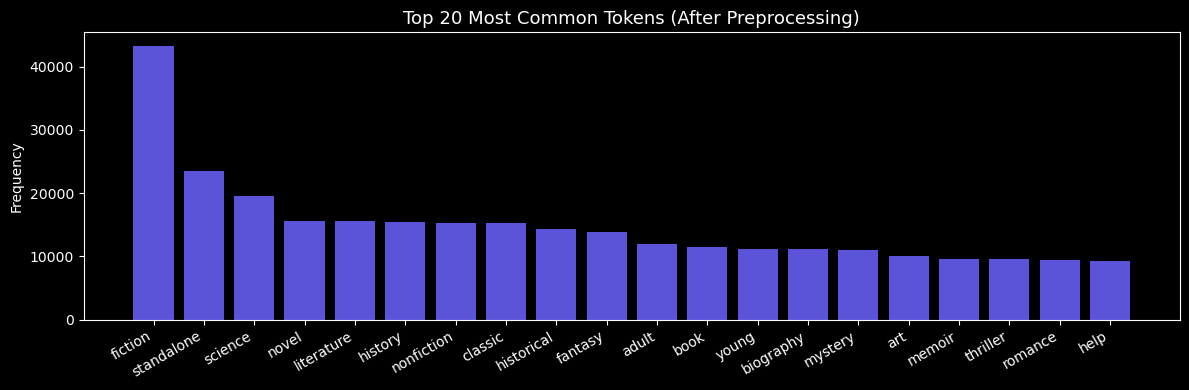

Total unique tokens in corpus: 58,297


In [19]:
all_tokens=' '.join(df['features'].dropna()).split()
fdist=FreqDist(all_tokens)
top_tokens=fdist.most_common(20)

words, counts=zip(*top_tokens)
fig, ax=plt.subplots(figsize=(12,4))
ax.bar(words, counts, color=ACCENT, edgecolor='none', alpha=0.85)
ax.set_title('Top 20 Most Common Tokens (After Preprocessing)', fontsize=13)
ax.set_ylabel('Frequency')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f'Total unique tokens in corpus: {len(fdist):,}')

---
5. TF-IDF Vectorization <br>
it will measure how important a word is to a documnet relative to the whole corpus

In [20]:
vectorizer=TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=2,              #it ignores terms appearning <2 books
    max_df=0.85,           #ignore terms in >85% of books
    sublinear_tf=True
)

tfidf_matrix=vectorizer.fit_transform(df['features'])

print(f'TF-IDF Matrix Shape  : {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]:,} books × {tfidf_matrix.shape[1]:,} features')
print(f'Matrix Sparsity      : {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1])):.2%}')
print(f'Non-zero entries     : {tfidf_matrix.nnz:,}')

TF-IDF Matrix Shape  : (14987, 15000)
  → 14,987 books × 15,000 features
Matrix Sparsity      : 99.44%
Non-zero entries     : 1,252,485


In [22]:
# show top tf-idf terms for a specific book
def top_tfidf_terms(book_title,n=15):
    idx=df[df['title'].str.lower()==book_title.lower()].index
    if idx.empty:
        print(f'Book not Found: {book_title}')
        return 
    idx=idx[0]
    feature_names=vectorizer.get_feature_names_out()
    row=tfidf_matrix[idx].toarray().flatten()
    top_idx=row.argsort()[::-1][:n]
    print(f"Top {n} TF-IDF terms for: '{df.iloc[idx]['title']}'")
    print(f"{'Term':<25} {'TF-IDF Score'}")
    print('-' * 38)
    for i in top_idx:
        print(f"{feature_names[i]:<25} {row[i]:.4f}")

top_tfidf_terms("Harry Potter and the Philosopher's Stone")

Top 15 TF-IDF terms for: 'Harry Potter and the Philosopher's Stone'
Term                      TF-IDF Score
--------------------------------------
hogwarts                  0.2231
harry                     0.2157
harry potter              0.2126
potter                    0.1956
school witchcraft         0.1614
witchcraft wizardry       0.1614
hogwarts school           0.1598
magic childrens           0.1569
dark lord                 0.1533
unbearable                0.1503
escaping                  0.1493
wizardry                  0.1484
classic audiobook         0.1445
brimming                  0.1445
adventure classic         0.1438


In [23]:
top_tfidf_terms("Twilight")

Top 15 TF-IDF terms for: 'Twilight'
Term                      TF-IDF Score
--------------------------------------
twilight                  0.2643
vampire                   0.2384
second part               0.2254
irrevocably               0.2202
fiction paranormal        0.2076
dominant                  0.2021
absolutely                0.1982
paranormal                0.1950
paranormal romance        0.1935
fantasy romance           0.1900
paranormal vampire        0.1811
positive                  0.1740
romance fiction           0.1705
urban fantasy             0.1648
adult fantasy             0.1632


---
6. **Cosine Similarity** <br>
it means the **angle** between two tf idf vectors <br>
score 1 means identicl <br>
score 0 means completely different <br>

In [27]:
#compute similarity for one book vs all others

def get_similarity_scores(book_title):
    idx=df[df['title'].str.lower().str.contains(book_title.lower(),na=False)].index
    if idx.empty:
        print(f'not found:{book_title}')
        return None, None
    idx=idx[0]
    query_vec=tfidf_matrix[idx]
    scores=cosine_similarity(query_vec,tfidf_matrix).flatten()
    return idx, scores

idx,scores=get_similarity_scores("Harry Potter and the Philosopher's Stone")
print(f'Similarity score with itself :   {scores[idx]:.4f}')
print(f'Min similarity               :   {scores.min():.4f}')
print(f'Max similarity (excluding self): {scores[scores < 1.0].max():.4f}')
print(f'Mean similarity              :   {scores.mean():.4f}')

Similarity score with itself :   1.0000
Min similarity               :   0.0000
Max similarity (excluding self): 0.5901
Mean similarity              :   0.0202


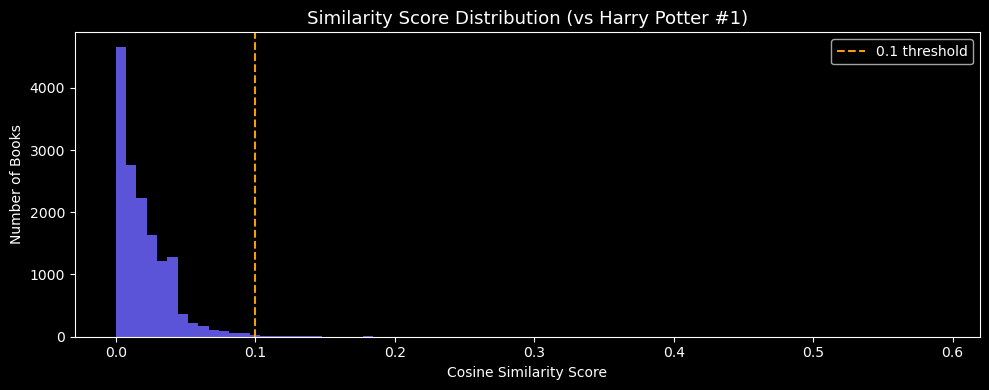

In [28]:
# Similarity score distribution
sample_scores = scores[scores < 1.0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sample_scores, bins=80, color=ACCENT, edgecolor='none', alpha=0.85)
ax.set_title("Similarity Score Distribution (vs Harry Potter #1)", fontsize=13)
ax.set_xlabel('Cosine Similarity Score')
ax.set_ylabel('Number of Books')
ax.axvline(0.1, color='#f59e0b', linestyle='--', label='0.1 threshold')
ax.legend()
plt.tight_layout()
plt.show()

---
7. Recommendation Function 

In [33]:
def recommend(title, top_n=8, verbose=True):
    '''
    recommend books similar to the given title
    returns a dataframe of top_n similar books
    '''
    #find book index
    matches=df[df['title'].str.lower().str.contains(title.lower(),na=False)]
    if matches.empty:
        print(f"book not found: '{title}'")
        return None
    
    idx=matches.index[0]
    query_title=df.iloc[idx]['title']

    #cosine similarity
    query_vec=tfidf_matrix[idx]
    sim_scores=cosine_similarity(query_vec,tfidf_matrix).flatten()

    #top n books
    top_idx=np.argsort(sim_scores)[::-1]
    top_idx=[i for i in top_idx if i !=idx][:top_n]

    if verbose:
        print(f"Query book : '{query_title}'")
        print(f"Genres     : {df.iloc[idx]['genres']}")
        print(f"Rating     : {df.iloc[idx]['rating']}")
        print(f"\nTop {top_n} Recommendations:")
        print('─' * 80)

    results=[]
    for rank, i in enumerate(top_idx, 1):
        book=df.iloc[i]
        results.append({
            'Rank':rank,
            'Title':book['title'],
            'Authors':book['authors'],
            'Genres':str(book['genres'])[:60],
            'Rating':book['rating'],
            'Pages':book['pages'],
            'Similarity Score':round(sim_scores[i],4)
        })
        if verbose:
            print(f"{rank:>2}. [{sim_scores[i]:.4f}] {book['title']} — {book['authors']}")

    return pd.DataFrame(results)


results_hp = recommend("Harry Potter and the Philosopher's Stone", top_n=8)

Query book : 'Harry Potter and the Philosopher's Stone'
Genres     : Fantasy,Fiction,Young Adult,Magic,Childrens,Middle Grade,Adventure,Classics,Audiobook,Science Fiction Fantasy
Rating     : 4.48

Top 8 Recommendations:
────────────────────────────────────────────────────────────────────────────────
 1. [0.5901] Harry Potter and the Sorcerer's Stone — J.K. Rowling,Mary GrandPré
 2. [0.5099] Harry Potter and the Chamber of Secrets — J.K. Rowling,Mary GrandPré
 3. [0.4764] Harry Potter and the Prisoner of Azkaban — J.K. Rowling
 4. [0.4738] Harry Potter and the Half-Blood Prince — J.K. Rowling
 5. [0.4585] Harry Potter Schoolbooks Box Set: Two Classic Books from the Library of Hogwarts School of Witchcraft and Wizardry — J.K. Rowling
 6. [0.4120] Harry Potter and the Goblet of Fire — J.K. Rowling,Mary GrandPré
 7. [0.4038] Harry Potter Collection — J.K. Rowling
 8. [0.3898] Harry Potter and the Order of the Phoenix — J.K. Rowling,Mary GrandPré


In [34]:
results_hp

,Rank,Title,Authors,Genres,Rating,Pages,Similarity Score
0,1,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré","Fantasy,Fiction,Young Adult,Magic,Childrens,Mi...",4.48,309,0.5901
1,2,Harry Potter and the Chamber of Secrets,"J.K. Rowling,Mary GrandPré","Fantasy,Young Adult,Fiction,Magic,Childrens,Mi...",4.43,341,0.5099
2,3,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,"Fantasy,Young Adult,Fiction,Magic,Childrens,Mi...",4.57,317,0.4764
3,4,Harry Potter and the Half-Blood Prince,J.K. Rowling,"Fantasy,Young Adult,Fiction,Magic,Childrens,Ad...",4.57,768,0.4738
4,5,Harry Potter Schoolbooks Box Set: Two Classic ...,J.K. Rowling,"Fantasy,Fiction,Young Adult,Childrens,Magic,Sc...",4.39,240,0.4585
5,6,Harry Potter and the Goblet of Fire,"J.K. Rowling,Mary GrandPré","Fantasy,Young Adult,Fiction,Magic,Childrens,Ad...",4.56,734,0.4120
6,7,Harry Potter Collection,J.K. Rowling,"Fantasy,Fiction,Young Adult,Magic,Adventure,Ch...",4.73,3342,0.4038
7,8,Harry Potter and the Order of the Phoenix,"J.K. Rowling,Mary GrandPré","Fantasy,Young Adult,Fiction,Magic,Childrens,Ad...",4.50,870,0.3898


In [35]:
results_twilight = recommend("Twilight", top_n=8)

Query book : 'Twilight'
Genres     : Young Adult,Fantasy,Romance,Fiction,Paranormal,Vampires,Paranormal Romance,Supernatural,Teen,Urban Fantasy
Rating     : 3.61

Top 8 Recommendations:
────────────────────────────────────────────────────────────────────────────────
 1. [0.3217] Fangs4Freaks — Serena Robar
 2. [0.2749] Evil Returns — Caroline B. Cooney
 3. [0.2611] Master of the Night — Angela Knight
 4. [0.2539] Witch Magic — Kelley Armstrong
 5. [0.2458] Kitty Goes to Washington — Carrie Vaughn
 6. [0.2333] Killers of the Dawn — Darren Shan
 7. [0.2306] Hunters of the Dusk — Darren Shan
 8. [0.2201] Vampire Mountain — Darren Shan


In [36]:
results_twilight

,Rank,Title,Authors,Genres,Rating,Pages,Similarity Score
0,1,Fangs4Freaks,Serena Robar,"Paranormal,Vampires,Young Adult,Romance,Parano...",3.75,224,0.3217
1,2,Evil Returns,Caroline B. Cooney,"Young Adult,Paranormal,Vampires,Horror,Fiction...",3.37,176,0.2749
2,3,Master of the Night,Angela Knight,"Romance,Paranormal Romance,Fantasy,Paranormal,...",3.88,296,0.2611
3,4,Witch Magic,Kelley Armstrong,"Fantasy,Paranormal,Urban Fantasy,Romance,Paran...",4.37,694,0.2539
4,5,Kitty Goes to Washington,Carrie Vaughn,"Fantasy,Urban Fantasy,Paranormal,Vampires,Shap...",3.87,342,0.2458
5,6,Killers of the Dawn,Darren Shan,"Fantasy,Young Adult,Horror,Paranormal,Vampires...",4.23,206,0.2333
6,7,Hunters of the Dusk,Darren Shan,"Fantasy,Young Adult,Horror,Paranormal,Vampires...",4.17,208,0.2306
7,8,Vampire Mountain,Darren Shan,"Fantasy,Young Adult,Horror,Paranormal,Vampires...",4.16,208,0.2201


---
8. Similarity Heatmap - for top books

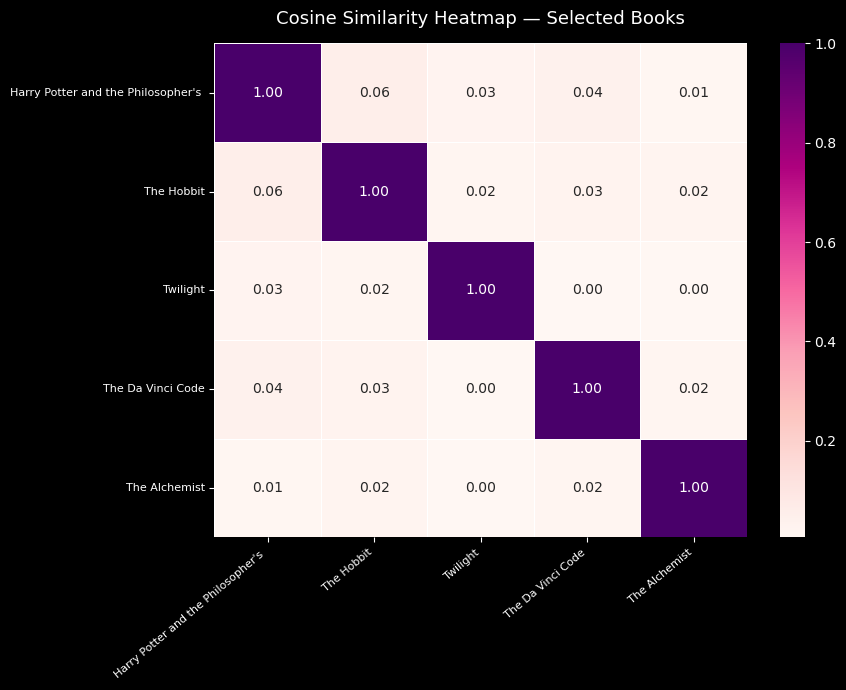

In [37]:
# Cross-similarity heatmap for a set of well-known books
sample_titles = [
    "Harry Potter and the Philosopher's Stone",
    "The Hobbit",
    "Twilight",
    "The Hunger Games",
    "Percy Jackson & the Olympians",
    "The Da Vinci Code",
    "Gone Girl",
    "The Alchemist",
]

indices = []
labels  = []
for t in sample_titles:
    match = df[df['title'].str.lower().str.contains(t.lower()[:12], na=False)]
    if not match.empty:
        indices.append(match.index[0])
        labels.append(df.iloc[match.index[0]]['title'][:35])

sub_matrix = tfidf_matrix[indices]
sim_matrix = cosine_similarity(sub_matrix)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt='.2f',
    cmap='RdPu',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Cosine Similarity Heatmap — Selected Books', fontsize=13, pad=14)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

---
9. Similarity Score Comparison by bar chart

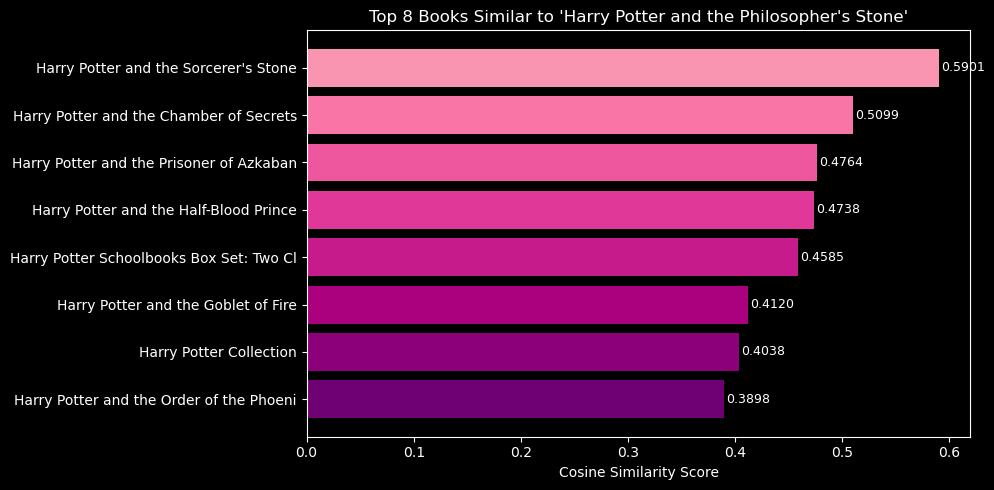

In [38]:
def plot_recommendations(book_title, top_n=8):
    recs = recommend(book_title, top_n=top_n, verbose=False)
    if recs is None: return

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.RdPu(np.linspace(0.4, 0.9, len(recs)))
    bars = ax.barh(recs['Title'].str[:40], recs['Similarity Score'],
                   color=colors, edgecolor='none')
    ax.invert_yaxis()
    ax.set_xlabel('Cosine Similarity Score')
    ax.set_title(f"Top {top_n} Books Similar to '{book_title[:40]}'", fontsize=12)

    for bar, score in zip(bars, recs['Similarity Score']):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

plot_recommendations("Harry Potter and the Philosopher's Stone")

In [40]:
df.tail()

,book_id,title,authors,series,language,description,genres,characters,places,awards,...,first_publish_year,publish_year,rated_1,rated_2,rated_3,rated_4,rated_5,isbn,isbn13,features
14982,12814,Dinosaurs: Back in Time,"Jane Belk Moncure,Lori Jacobson,Linda Hohag",Standalone,English,NaN,"Art,Biography,Business,Children's,Christian,Cl...",NaN,NaN,NaN,...,NaN,1990,0,0,0,0,0,0516081063,9780516081069,dinosaur back time jane belk moncure lori jaco...
14983,19978,"Monetary Policy, Financial Stability, And Cent...",Narendra Jadhav,Standalone,English,NaN,"Art,Biography,Business,Children's,Christian,Cl...",NaN,NaN,NaN,...,NaN,2006,0,0,0,0,0,1403929025,9781403929020,monetary policy financial stability central ba...
14984,19969,Names of Snow,Judi Beach,Standalone,English,"CATALOG COPY DESCRIPTION Mama, what is snow? a...","Art,Biography,Business,Children's,Christian,Cl...",NaN,NaN,NaN,...,NaN,2003,0,0,0,0,0,NaN,9780786826865,name snow judi beach art biography business ch...
14985,19871,Global Swap Markets,Satyajit Das,Standalone,English,This text provides a country-by-country analys...,"Art,Biography,Business,Children's,Christian,Cl...",NaN,NaN,NaN,...,1991.0,1991,0,0,0,0,0,1873446101,9781873446102,global swap market satyajit da art biography b...
14986,19869,Structured Products Volume 1: Exotic Options; ...,Satyajit Das,Standalone,English,"consists of,and,covering applications of deriv...","Art,Biography,Business,Children's,Christian,Cl...",NaN,NaN,NaN,...,NaN,2005,0,0,0,0,0,0470821663,9780470821664,structured product volume exotic option intere...


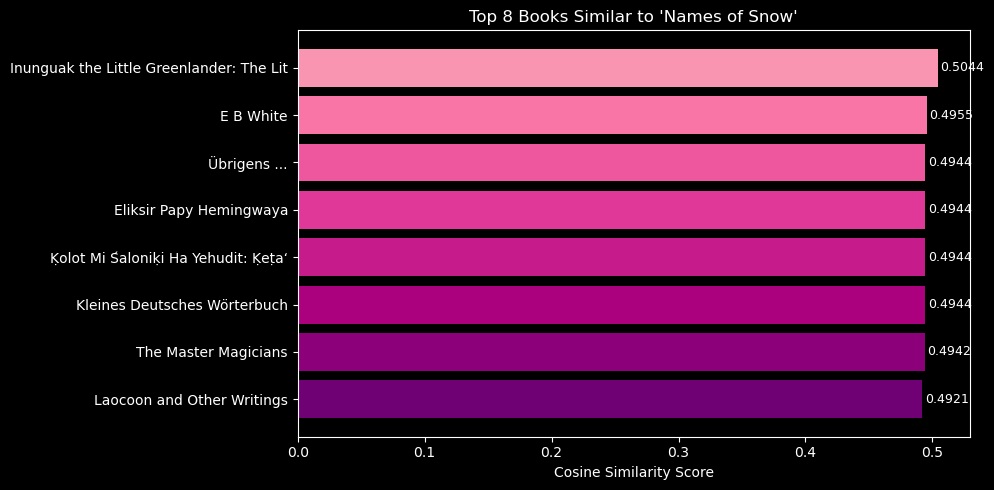

In [41]:
plot_recommendations("Names of Snow")

---
10. saving the model

In [43]:
import os

model_path = '../models/recommender.pkl'

with open(model_path, 'wb') as f:
    pickle.dump({
        'vectorizer':   vectorizer,
        'tfidf_matrix': tfidf_matrix,
        'df':           df
    }, f)

size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f'Model saved to: {model_path}')
print(f'Model size    : {size_mb:.1f} MB')

Model saved to: ../models/recommender.pkl
Model size    : 46.6 MB


---
## 11. Pipeline Summary

| Step | Function | Input → Output |
|------|----------|----------------|
| 1. Text Cleaning | `clean_text()` | Raw string → lowercase, letters only |
| 2. Tokenization | `tokenize()` | String → list of tokens |
| 3. Stopword Removal | `remove_stopwords()` | Token list → filtered list |
| 4. Lemmatization | `lemmatize()` | Token list → root-form list |
| 5. Feature Building | `build_features()` | DataFrame row → single feature string |
| 6. TF-IDF | `TfidfVectorizer` | Feature strings → sparse matrix (14987 × 15000) |
| 7. Recommendation | `recommend()` | Book title → Top-N similar books |

**Total books:** 14,987 (after dedup)
**Vocabulary size:** 15,000 features (unigrams + bigrams)